In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from tqdm.auto import tqdm
from tqdm.notebook import tqdm as tqdm_nb

import io
import imageio

from torch.utils.data import DataLoader, Dataset
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets,transforms
import torchvision.transforms as tfs

from torch.optim.lr_scheduler import ReduceLROnPlateau,OneCycleLR,CyclicLR

In [3]:
BATCH_SIZE = 128
CHANNELS = 1
HEIGHT = 28
WIDTH = 28
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

transform = tfs.Compose([
    tfs.ToTensor()
])

train_dataset = datasets.MNIST(root='./mnist_data/',train=True ,transform = transform,download=True)
test_dataset = datasets.MNIST(root='./mnist_data/',train=False,transform = transform,download=False)

dataloader = {
    'train':DataLoader(dataset=train_dataset,batch_size=BATCH_SIZE,shuffle=False),
    'test':DataLoader(dataset=test_dataset,batch_size=BATCH_SIZE,shuffle=False)
}

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]


Extracting ./mnist_data/MNIST/raw/train-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28.9k/28.9k [00:00<00:00, 468kB/s]


Extracting ./mnist_data/MNIST/raw/train-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.37MB/s]


Extracting ./mnist_data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./mnist_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4.54k/4.54k [00:00<00:00, 5.80MB/s]

Extracting ./mnist_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./mnist_data/MNIST/raw



In [4]:
len(train_dataset.data) , len(train_dataset.targets) , len(test_dataset.data) , len(test_dataset.targets)

(60000, 60000, 10000, 10000)

In [5]:
classes = train_dataset.classes
classes

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

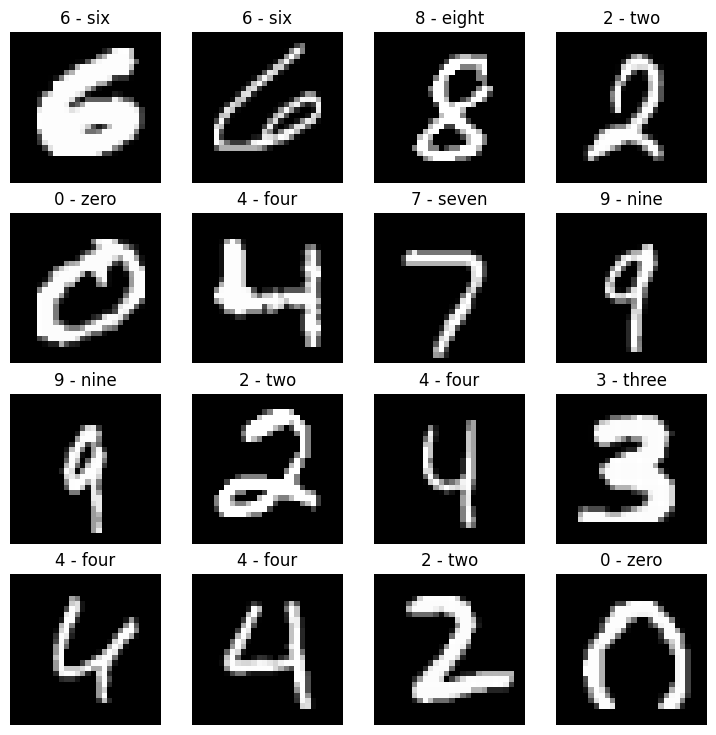

In [6]:
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4

for i in range(1,cols*rows+1):
    random_idx = torch.randint(0,len(train_dataset),size=[1]).item()
    img,label = train_dataset[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(classes[label])
    plt.axis(False);

In [7]:
def check_reconstruction(model,dataset,num_samples=10,z_dim=2,device="cuda"):
    # sample num_samples images from dataset
    sample_images = []
    sample_labels = []
    for i in range(num_samples):
        idx = np.random.randint(0,len(dataset))
        img,label = dataset[idx]
        sample_images.append(img)
        sample_labels.append(label)
    sample_images = torch.stack(sample_images).to(device)
    sample_labels = torch.tensor(sample_labels).to(device)
    model.eval()
    with torch.no_grad():
        reconstructed_images, mu, log_var = model(sample_images)
        reconstructed_images = reconstructed_images.cpu()
        sample_images = sample_images.cpu()

        # Plot the original and reconstructed images
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples, 2.5))
    for i in range(num_samples):
        axes[0, i].imshow(sample_images[i,:].reshape((28,28)), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(reconstructed_images[i,:].reshape((28,28)), cmap="gray")
        axes[1, i].axis("off")

    plt.show()

In [8]:
def generate_images(model, n_rows = 8, z_dim=2, device="cuda"):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_rows,n_rows, z_dim).to(device) # Sample random latent vectors from a normal distribution
        generated_images = model.decoder(z).cpu() # Decode the latent vectors into images

    # Plot the generated images
    fig, axes = plt.subplots(n_rows, n_rows, figsize=(n_rows, n_rows))
    for i in range(n_rows):
        for j in range(n_rows):
            axes[i,j].imshow(generated_images[i, j,:].reshape(28,28), cmap="gray")
            axes[i,j].axis("off")

    plt.show()

In [9]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        
        # encoder part
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        
        # decoder part
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)
        
    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h) # mu, log_var
    
    def sampling(self, mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mu) # return z sample
        
    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return F.sigmoid(self.fc6(h)) 
    
    def forward(self, x):
        mu, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mu, log_var)
        return self.decoder(z), mu, log_var

class KLDivergenceLoss(nn.Module):
    def forward(self, mu, log_var):
        return -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

class EarlyStopping2:
    def __init__(self, patience=5):
        self.best_loss = np.inf
        self.patience = 0
        self.patience_limit = patience

    def step(self, loss):
        if loss < self.best_loss:
            self.best_loss = loss
            self.patience = 0
        else:
            self.patience += 1

    def is_stop(self):
        return self.patience >= self.patience_limit
        
class VAELoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.kl_divergence = KLDivergenceLoss()
        self.reconstruction_loss = nn.BCELoss(reduction = "sum")

    def forward(self, mu, log_var, outputs, targets, beta=1e-4):
        kl_loss = self.kl_divergence(mu, log_var)
        recon_loss = self.reconstruction_loss(outputs, targets.view(-1,784))
        return beta * kl_loss + recon_loss

In [10]:
def init_weights(m):
    if isinstance(m, nn.Linear) or isinstance(m, nn.Conv2d):
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.zeros_(m.bias)

In [15]:
# Training Loop
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
z_dim = 2
model = VAE(x_dim=784, h_dim1= 512, h_dim2=256, z_dim=z_dim).to(DEVICE)
model.apply(init_weights)
criterion = VAELoss()

# optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-5)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
loss_kl = KLDivergenceLoss()
loss_bce = nn.BCELoss()

EPOCHS = 100
early_stopping = EarlyStopping2(patience=5)
train_losses, test_losses = [], []

for epoch in tqdm(range(EPOCHS)):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    model.train()
    beta = 1.0
    train_loss = 0

    for batch, (images, _) in enumerate(dataloader['train']):  
        images = images.to(DEVICE)

        optimizer.zero_grad()
        outputs, mu, log_var = model(images)
        loss = criterion(mu, log_var, outputs, images.float(), beta=beta)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient Clipping
        optimizer.step()
        train_loss += loss.item() /len(images)

        if batch % 100 == 0:
            loss_kl_val = loss_kl(mu,log_var)/len(images)
            loss_bce_val = loss_bce(outputs,images.float().view(-1,784))/len(images)
            print(f"Batch {batch}, Loss: {loss.item()/len(images):.5f},Loss KL: {loss_kl_val.item():.5f},Loss BCE: {loss_bce_val.item():.5f} ")

    train_loss /= len(dataloader['train'])
    train_losses.append(train_loss)

    # Validation loop
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for images, _ in dataloader['test']:
            images = images.to(DEVICE)
            outputs, mu, log_var = model(images)
            loss = criterion(mu, log_var, outputs, images.float(), beta=beta)
            test_loss += loss.item() /len(images)

    test_loss /= len(dataloader['test'])
    test_losses.append(test_loss)

    print(f"Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}")

    scheduler.step(test_loss)  # Adjust learning rate dynamically
    early_stopping.step(test_loss)
    if early_stopping.is_stop():
        print("Early stopping triggered!")
        break

  0%|          | 0/100 [00:00<?, ?it/s]


Epoch 1/100
Batch 0, Loss: 543.79095,Loss KL: 0.25504,Loss BCE: 0.00542 
Batch 100, Loss: 190.07979,Loss KL: 3.41827,Loss BCE: 0.00186 
Batch 200, Loss: 178.59036,Loss KL: 4.35927,Loss BCE: 0.00174 
Batch 300, Loss: 162.72664,Loss KL: 4.33484,Loss BCE: 0.00158 
Batch 400, Loss: 175.45497,Loss KL: 4.85227,Loss BCE: 0.00170 
Train loss: 189.06438 | Test loss: 171.78243

Epoch 2/100
Batch 0, Loss: 164.37718,Loss KL: 4.61238,Loss BCE: 0.00159 
Batch 100, Loss: 167.92761,Loss KL: 4.49187,Loss BCE: 0.00163 
Batch 200, Loss: 167.66824,Loss KL: 4.76105,Loss BCE: 0.00162 
Batch 300, Loss: 156.01521,Loss KL: 4.99607,Loss BCE: 0.00150 
Batch 400, Loss: 167.98224,Loss KL: 5.25600,Loss BCE: 0.00162 
Train loss: 165.41839 | Test loss: 163.62413

Epoch 3/100
Batch 0, Loss: 155.08978,Loss KL: 4.97464,Loss BCE: 0.00150 
Batch 100, Loss: 160.80379,Loss KL: 5.16805,Loss BCE: 0.00155 
Batch 200, Loss: 162.56525,Loss KL: 5.29240,Loss BCE: 0.00157 
Batch 300, Loss: 152.07762,Loss KL: 5.44492,Loss BCE: 0.00

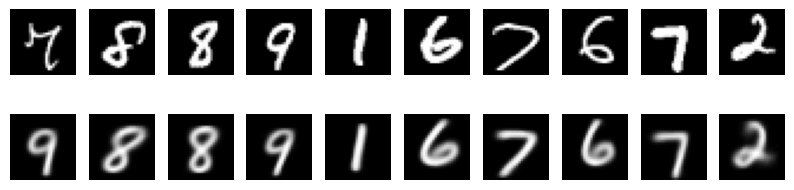

In [23]:
check_reconstruction(model,test_dataset,num_samples=10,z_dim=z_dim,device="cuda")

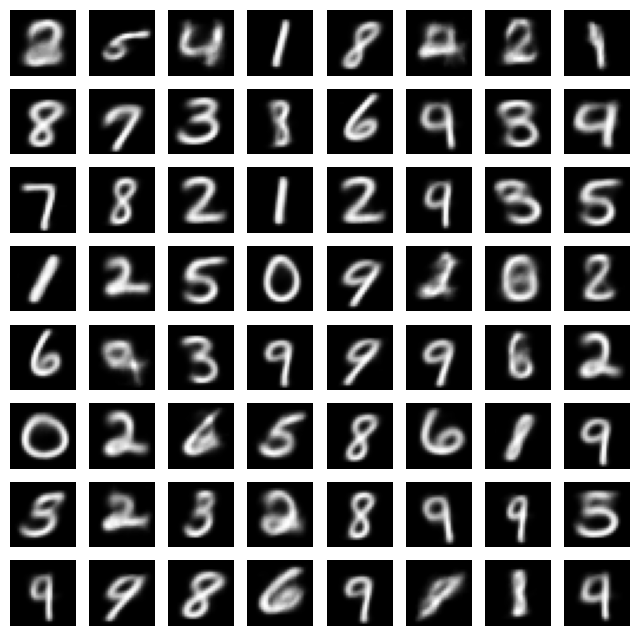

In [24]:
generate_images(model, n_rows = 8, z_dim=z_dim, device="cuda")

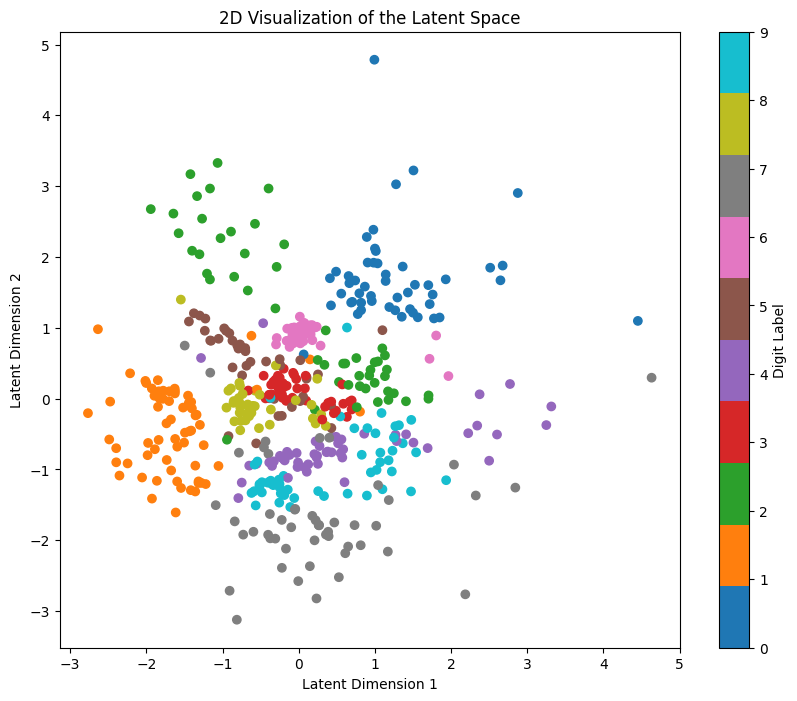

In [40]:
def visualize_latent_space(vae, dataloader, n=500, device = "cuda"):
    """Encodes n images into the latent space and plots their 2D embeddings with digit colors."""
    
    # Set VAE to evaluation mode
    vae.eval()
    
    # Storage for embeddings and labels
    embeddings, labels = [], []
    
    with torch.no_grad():
        for images, digit_labels in dataloader:
            images = images.to(device).view(-1,784)
            # print(images.shape)
            mu, log_var = vae.encoder(images)  # Encode images
            
            z = mu  # Use the mean as the latent representation
            
            embeddings.append(z.cpu().numpy())
            labels.append(digit_labels.cpu().numpy())

            if len(embeddings) * len(images) >= n:
                break

    # Convert lists to arrays
    embeddings = np.concatenate(embeddings, axis=0)[:n]
    labels = np.concatenate(labels, axis=0)[:n]
    
    # Scatter plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings[:, 0], embeddings[:, 1], c=labels, cmap='tab10', alpha=1)
    plt.colorbar(scatter, label="Digit Label")
    plt.xlabel("Latent Dimension 1")
    plt.ylabel("Latent Dimension 2")
    plt.title("2D Visualization of the Latent Space")
    plt.show()

# Load the MNIST dataset
# transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])  # Flatten images
# mnist_train = datasets.MNIST(root="./data", train=True, transform=transform, download=True)

# Run visualization
visualize_latent_space(model, dataloader['train'], n=500)

In [28]:
class CNNClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                # nn.MaxPool2d(2, 2), # Downsample to (16, 14, 14)
                nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
                nn.ReLU(),
                # nn.MaxPool2d(2, 2), # Downsample to (32, 7, 7)
                nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2, 2) # Downsample to (64, 3, 3)
                )

        self.fc_layers = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64 * 3 * 3, 128),
                nn.ReLU(),
                nn.Linear(128, num_classes) # Output logits for 10 digits
                )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x # Logits output

In [29]:
classifier = CNNClassifier().to(DEVICE)
clf_optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)
clf_loss_fn = nn.CrossEntropyLoss()

# Train classifier
num_epochs = 10
for epoch in range(num_epochs):
    total_loss, correct, total = 0, 0, 0
    for batch, (images, labels) in enumerate(dataloader['train']):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Forward pass
        logits = classifier(images)
        loss = clf_loss_fn(logits, labels)

        # Backpropagation
        clf_optimizer.zero_grad()
        loss.backward()
        clf_optimizer.step()

        # Compute training accuracy
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += len(images)
        total_loss += loss.item()
        
    model.eval()
    tot_test_loss, test_correct, test_total = 0,0,0
    with torch.no_grad():
        for test_images, test_labels in dataloader['test']:
            test_images, test_labels = test_images.to(DEVICE), test_labels.to(DEVICE)
            
            #print(images.shape,labels.shape)
            logits = classifier(test_images)
            loss = clf_loss_fn(logits,test_labels)
            
            # Compute test accuracy
            test_preds = logits.argmax(dim=1)
            test_correct += (test_preds==test_labels).sum().item()
            test_total += len(test_images)
            tot_test_loss += loss.item()

    
    test_acc = test_correct / test_total * 100
    train_acc = correct / total * 100
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(dataloader['train']):.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

Epoch 1/10, Loss: 0.3909, Train Acc: 87.98%, Test Acc: 96.92%
Epoch 2/10, Loss: 0.0897, Train Acc: 97.20%, Test Acc: 97.97%
Epoch 3/10, Loss: 0.0609, Train Acc: 98.16%, Test Acc: 98.24%
Epoch 4/10, Loss: 0.0463, Train Acc: 98.60%, Test Acc: 98.49%
Epoch 5/10, Loss: 0.0363, Train Acc: 98.89%, Test Acc: 98.59%
Epoch 6/10, Loss: 0.0294, Train Acc: 99.09%, Test Acc: 98.49%
Epoch 7/10, Loss: 0.0237, Train Acc: 99.27%, Test Acc: 98.24%
Epoch 8/10, Loss: 0.0221, Train Acc: 99.27%, Test Acc: 98.18%
Epoch 9/10, Loss: 0.0189, Train Acc: 99.41%, Test Acc: 98.47%
Epoch 10/10, Loss: 0.0175, Train Acc: 99.44%, Test Acc: 98.60%


In [109]:
class LatentOptimizer(nn.Module):
    def __init__(self, z_dim):
        super().__init__()
        self.mu = nn.Parameter(torch.zeros(z_dim))  # Learnable mean vector
        self.M = nn.Parameter(torch.zeros(z_dim, z_dim))  # Lower triangular matrix

    def forward(self, X):
        # Apply the diagonal exponential transform correctly
        # D_L = torch.tril(self.M)
        D_L = self.M
        D_L_diag = torch.diagonal(D_L)  
        D_L = D_L - torch.diag(D_L_diag) + torch.diag(torch.exp(D_L_diag))  

        # Expand mu properly
        mu_matrix = self.mu.unsqueeze(1)  # Shape: (z_dim, 1)

        # Apply the affine transformation
        Z = mu_matrix + D_L @ X  # Shape: (z_dim, N)

        return Z

In [129]:
def score_function_k(k):
    def score_k(proba):
        return proba[:,k]
    return score_k
    
def train_latent_optimizer_on_mnist(score_function,
                                    vae,
                                    classifier,
                                    z_dim = 2,
                                    lr = 1e-2,
                                    num_epochs = 1000, 
                                    batch_size = 64,
                                    tol = 1e-4, 
                                    device = "cuda",
                                    verbose = True):
    vae.eval()
    classifier.eval()

    latent_optimizer = LatentOptimizer(z_dim).to(device)
    optimizer = torch.optim.Adam(latent_optimizer.parameters(), lr=lr)
    
    sampling_proba = [0]
    mus = [latent_optimizer.mu.cpu().detach().numpy()]
    Ms = [latent_optimizer.M.cpu().detach().numpy()]
    
    for epoch in range(num_epochs):
        # print(mus[-1].cpu().detach().numpy(),Ms[-1].cpu().detach().numpy())
        optimizer.zero_grad()

        X = torch.randn(z_dim, batch_size).to(device)
        
        Z = latent_optimizer(X)

        generated_images = model.decoder(Z.T).reshape(batch_size,1,28,28)

        logits = classifier(generated_images) 
        probabilities = nn.Softmax()(logits)

        scores = score_function(probabilities)

        loss = -scores.mean()
        
        
        loss.backward()
        optimizer.step()

        sampling_proba.append(-loss.item())
        mus.append(latent_optimizer.mu.cpu().detach().numpy())
        Ms.append(latent_optimizer.M.cpu().detach().numpy())
        if verbose and epoch % 50 == 0: 
            print(f"Epoch {epoch}: Loss = {loss.item():.4f}")
        if np.abs(1-torch.abs(loss).item()) < tol:
            print("Early Stopping triggered after",epoch,"epochs with final mean condition probability:",-loss.item())
            break
    return latent_optimizer, mus, Ms, sampling_proba

In [127]:
def sample_and_generate(latent_optimizer, vae, N=10, DEVICE = "cuda"):
    """Samples N points from the optimized latent distribution and generates MNIST digits."""
    # Extract optimized mu and M
    mu_opt = latent_optimizer.mu.to(DEVICE)  # Shape: (z_dim,)
    M_opt = latent_optimizer.M.to(DEVICE)   # Shape: (z_dim, z_dim)

    # Construct D(M) (lower triangular with exp on diagonal)
    # D_L = torch.tril(M_opt)
    D_L = M_opt
    D_L_diag = torch.diagonal(D_L)
    D_L = D_L - torch.diag(D_L_diag) + torch.diag(torch.exp(D_L_diag))

    # Sample from N(0, I)
    z_dim = mu_opt.shape[0]
    X = torch.randn(z_dim, N).to(DEVICE)  # Shape: (z_dim, N)

    # Apply affine transformation
    Z = mu_opt.unsqueeze(1) + D_L @ X  # Shape: (z_dim, N)

    # Decode to generate images
    generated_images = vae.decoder(Z.T).view(N, 1, 28, 28)  # Ensure proper shape

    # Visualize results
    fig, axes = plt.subplots(1, N, figsize=(10, 2))
    for i, ax in enumerate(axes):
        ax.imshow(generated_images[i].detach().cpu().squeeze(), cmap='gray')
        ax.axis("off")
    plt.show()

    return generated_images  # Return for further analysis if needed

In [130]:
k = np.random.randint(10)

latent_optimizer, mus, Ms, sampling_proba = train_latent_optimizer_on_mnist(score_function_k(k),
                                                                            model,
                                                                            classifier,
                                                                            z_dim = 2,
                                                                            lr = 1e-2,
                                                                            num_epochs = 10, 
                                                                            batch_size = 64,
                                                                            tol = 1e-4, 
                                                                            device = "cuda")

Epoch 0: Loss = -0.1521


Early Stopping triggered after 283 epochs with final mean condition probability: 0.9999998807907104
0


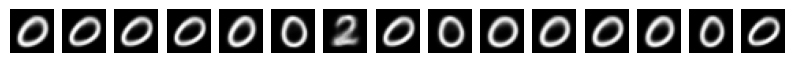

Early Stopping triggered after 306 epochs with final mean condition probability: 0.9999785423278809
1


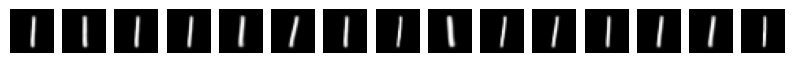

2


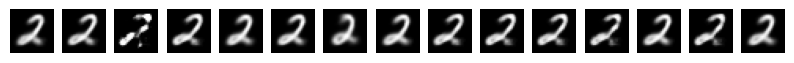

Early Stopping triggered after 632 epochs with final mean condition probability: 0.999988317489624
3


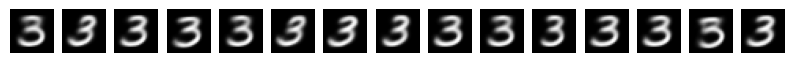

Early Stopping triggered after 400 epochs with final mean condition probability: 0.9999975562095642
4


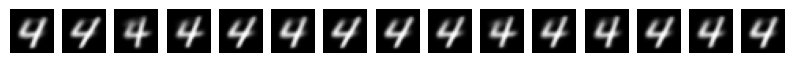

Early Stopping triggered after 436 epochs with final mean condition probability: 0.9999079704284668
5


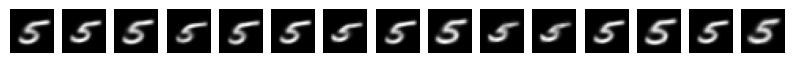

Early Stopping triggered after 340 epochs with final mean condition probability: 0.9999929666519165
6


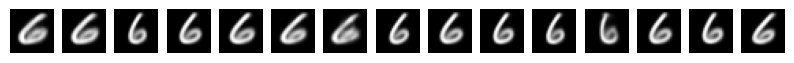

Early Stopping triggered after 620 epochs with final mean condition probability: 0.9999058842658997
7


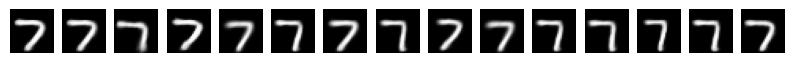

Early Stopping triggered after 641 epochs with final mean condition probability: 0.9999343156814575
8


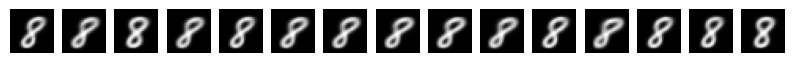

Early Stopping triggered after 778 epochs with final mean condition probability: 0.9999660849571228
9


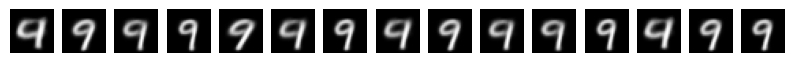

In [131]:
all_l_os, all_mus, all_Ms, all_s_ps = [],[],[],[]
for k in range(10):
    latent_optimizer, mus, Ms, sampling_proba = train_latent_optimizer_on_mnist(score_function_k(k),
                                                                            model,
                                                                            classifier,
                                                                            z_dim = 2,
                                                                            lr = 1e-2,
                                                                            num_epochs = 1000, 
                                                                            batch_size = 64,
                                                                            tol = 1e-4, 
                                                                            device = "cuda",
                                                                            verbose = False)
    print(k)
    
    generated_images = sample_and_generate(latent_optimizer, model, N=15)
    all_l_os.append(latent_optimizer)
    all_mus.append(mus)
    all_Ms.append(Ms)
    all_s_ps.append(sampling_proba)

In [64]:
import seaborn as sns
from scipy.stats import multivariate_normal

In [167]:
def visualize_latent_space(vae, 
                           dataloader, 
                           mu_list, 
                           M_list, 
                           num_samples=500,
                           device = "cuda"):
    vae.eval()  # Set VAE to evaluation mode
    latent_points = []
    labels = []

    # Sample images and encode them
    with torch.no_grad():
        for i, (x, y) in enumerate(dataloader):
            x = x.to(next(vae.parameters()).device)  # Move to correct device
            mu_enc, log_var_enc = vae.encoder(x.view(-1,784))  # Encode images
            z_enc = mu_enc.cpu().numpy()
            latent_points.append(z_enc)
            labels.append(y.cpu().numpy())
            if len(latent_points) * x.size(0) >= num_samples:
                break

    # Concatenate results
    latent_points = np.concatenate(latent_points, axis=0)
    labels = np.concatenate(labels, axis=0)

    # Prepare the Gaussian distribution from optimized parameters
    sigma_list = []
    for k in range(len(mu_list)):
        mu_np = mu_list[k]
        M_np = M_list[k]
        D_M = np.tril(M_np)  # Ensure it's lower triangular
        Diag_M = np.diag(D_M)
        D_M = M_np - np.diag(Diag_M) + np.diag(np.exp(Diag_M)) # Apply exponent on diagonal
        cov_matrix = D_M @ D_M.T  # Compute Σ from Cholesky factorization
        sigma_list.append(cov_matrix)
    
    # Create a meshgrid to evaluate the Gaussian distribution
    x_range = np.linspace(latent_points[:, 0].min()-1, latent_points[:, 0].max()+1, 100)
    y_range = np.linspace(latent_points[:, 1].min()-1, latent_points[:, 1].max()+1, 100)
    X, Y = np.meshgrid(x_range, y_range)
    pos = np.dstack((X, Y))

    Z_list = []
    for k in range(len(mu_list)):
        rv = multivariate_normal(mean=mu_list[k], cov=sigma_list[k])
        Z = rv.pdf(pos)  # Probability density function over the grid
        Z_list.append(Z)

    # Plot the latent space with color-coded points
    # plt.figure(figsize=(10, 8))
    fig,axes = plt.subplots(1,len(mu_list)+1,figsize = (5*(len(mu_list)+2),5))
    sns.scatterplot(x=latent_points[:, 0], y=latent_points[:, 1], hue=labels, palette="tab10", alpha=0.7, edgecolor='k',ax = axes[-1])

    # Overlay the Gaussian distribution as a heatmap
    for k in range(0,len(mu_list)):
        contourk = axes[k].contourf(X, Y, Z_list[k], levels=20, cmap='viridis', alpha=0.2)

    # Mark the optimized mean location
        axes[k].scatter(mu_list[k][0], mu_list[k][1], color="red", marker="x", s=100, label="Optimized μ")

        axes[k].set_xlabel("Latent Dimension 1")
        axes[k].set_ylabel("Latent Dimension 2")
        axes[k].set_title("Latent Space Visualization with Gaussian Distribution")
        axes[k].legend()
    # fig.colorbar(contourk, label="Density",ax = axes[k])
    plt.show()

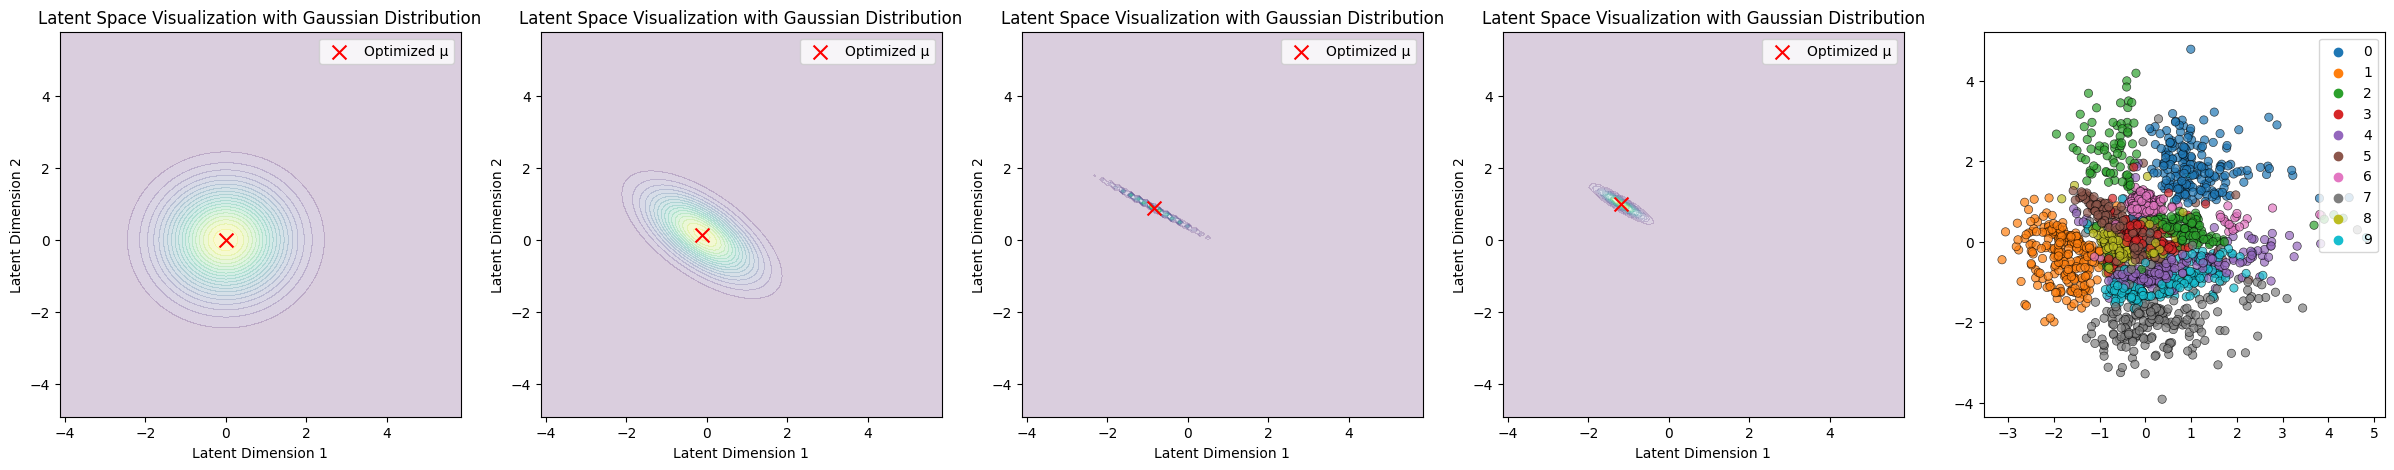

In [170]:
k = 5
mus_test = all_mus[k]
Ms_test = all_Ms[k]
# test_idx = np.random.randint(len(mus_test))
# test_idx = 200
# mu_test = mus_test[test_idx]
# M_test = Ms_test[test_idx]

idx_list = [0,len(mus_test)//4, 3*len(mus_test)//4, -1]
mu_list = [mus_test[idx] for idx in idx_list]
M_list = [Ms_test[idx] for idx in idx_list]
visualize_latent_space(model, 
                       dataloader['train'],
                       mu_list,
                       M_list, 
                       num_samples=2000)

In [ ]:
def score_function_k_l(k,l):
    def score_k_l(proba):
        return proba[:,k]/2 + proba[:,l]/2
    return score_k_l

k,l = 7,3

latent_optimizer, mus, Ms, sampling_proba = train_latent_optimizer_on_mnist(score_function_k_l(k,l),
                                                                            model,
                                                                            classifier,
                                                                            z_dim = 2,
                                                                            lr = 1e-2,
                                                                            num_epochs = 2000, 
                                                                            batch_size = 64,
                                                                            tol = 1e-4, 
                                                                            device = "cuda")

generated_images = sample_and_generate(latent_optimizer, model, N=15)